In [73]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os
import shutil

Changes:
- freq_number = 50
- Cosine Annealing instead of StepLR (reduces learning rate at fixed steps)
- nn.SiLU() instead of nn.ReLU() (can improve gradient flow)

1. SETTING UP ENVIRONMENT

In [74]:
# Define directory for saving results

filepath = 'Tests/Fourier/19'
script_dir = os.path.dirname('mlp fourier.ipynb')
results_dir = os.path.join(script_dir, filepath + '/')

if not os.path.isdir(results_dir):
    os.makedirs(results_dir)

In [75]:
# Set random seed for reproducibility

torch.manual_seed(7)  # PyTorch seed
np.random.seed(7)     # NumPy seed

In [76]:
# Select computation device

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


2. HYPERPARAMETER CONFIGURATION

In [77]:
num_classes = 7       # Number of classes (coins)
epochs = 200          # Number of training epochs
batch_size = 16       # Mini-batch size
learning_rate = 0.001 # Initial learning rate
freq_number = 50      # Number of frequency features selected

3. LOAD AND PROCESS DATA

In [78]:
# Load dataset from file
data = np.load('./coin_data.npy')

In [79]:
def compute_fft_features(data, sample_rate=204000):
    
    """
    Computes FFT features from time-series data.
    
    Parameters:
        data (numpy array): Input dataset where first column is the label.
        sample_rate (int): Sampling rate of the audio.
    Returns:
        labels (numpy array): Extracted labels.
        fft_magnitudes (numpy array): FFT magnitude values.
        freqs (numpy array): Corresponding frequency values.
    """

    labels = data[:, 0]  # Extract labels
    signals = data[:, 1:]  # Extract time-series signals
    N = signals.shape[1]  # Number of time points00

    try:
        fft_magnitudes = np.load('./fft_magnitudes.npy')
    except:
        fft_features = np.fft.rfft(signals, axis=1) # Compute FFT
        fft_magnitudes = np.abs(fft_features)  # Compute magnitude

    freqs = np.fft.rfftfreq(N, d=1/sample_rate) # Compute actual freq. val.

    return labels, fft_magnitudes, freqs

In [80]:
def extract_top_k_frequencies_with_info(fft_magnitudes, freqs, k):
    """
    Extracts the top K most important frequencies and concatenates frequency and amplitude values.
    
    Parameters:
        fft_magnitudes (numpy array): FFT magnitude values.
        freqs (numpy array): Corresponding frequency values.
        k (int): Number of top frequencies to extract.
    Returns:
        combined_features (numpy array): Feature set with frequencies and amplitudes.
    """
   
    top_k_indices = np.argsort(-fft_magnitudes, axis=1)[:, :k]  # Get indices of top K frequencies
    top_k_magnitudes = np.take_along_axis(fft_magnitudes, top_k_indices, axis=1)
    top_k_frequencies = np.take(freqs, top_k_indices)
    combined_features = np.hstack([top_k_frequencies, top_k_magnitudes])
    return combined_features, top_k_indices, top_k_magnitudes, top_k_frequencies

In [81]:
# Compute FFT features
labels, fft_magnitudes, freqs = compute_fft_features(data)
combined_features, top_k_indices, top_k_magnitudes, top_k_frequencies = extract_top_k_frequencies_with_info(fft_magnitudes, freqs, k=freq_number)

(384513,)
(1094, 384513)


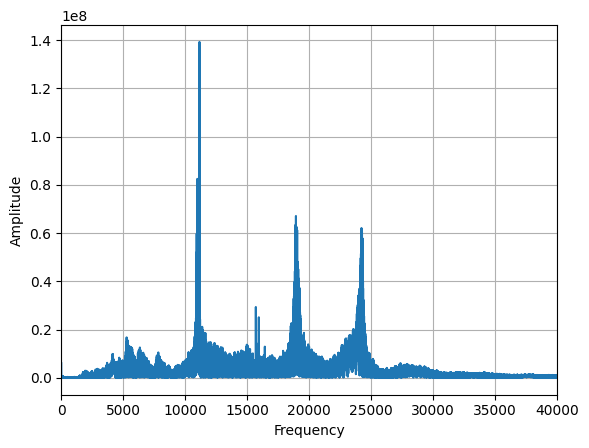

(384513,)
(1094, 384513)


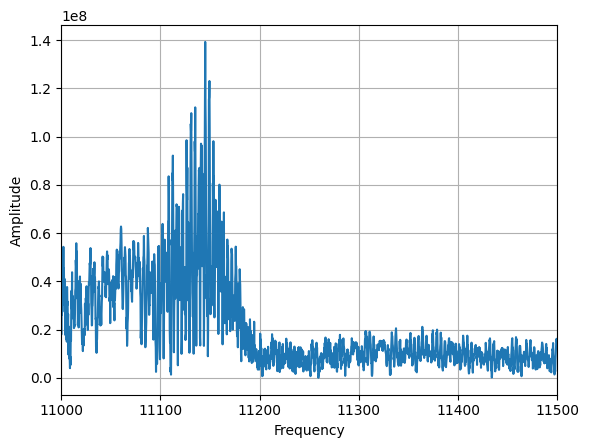

Shape of processed data for MLP: (1094, 100)
Shape of fft_magnitudes: (1094, 384513)
First 10 freq. in Hz: [0.         0.2652713  0.53054261 0.79581391 1.06108522 1.32635652
 1.59162783 1.85689913 2.12217044 2.38744174]



In [82]:
print(freqs.shape)
print(fft_magnitudes.shape)
plt.figure()
plt.plot(freqs, fft_magnitudes[0])
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.xlim(0, 40000)
plt.grid()
plt.show()

print(freqs.shape)
print(fft_magnitudes.shape)
plt.figure()
plt.plot(freqs, fft_magnitudes[0])
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.xlim(11000,11500)
plt.grid()
plt.show()

print("Shape of processed data for MLP:", combined_features.shape)
print("Shape of fft_magnitudes:", fft_magnitudes.shape)
print("First 10 freq. in Hz:", freqs[:10])
print()

4. DEFINE MLP CLASSIFIER

In [83]:
class MLPClassifier(nn.Module):
    """Multi-Layer Perceptron (MLP) classifier for FFT-based features."""
    def __init__(self, input_size, num_classes):
        super(MLPClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.relu1 = nn.SiLU()
        self.dropout1 = nn.Dropout(0.2)
        
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.relu2 = nn.SiLU()
        self.dropout2 = nn.Dropout(0.2)
        
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.relu3 = nn.SiLU()
        self.dropout3 = nn.Dropout(0.2)
        
        self.fc4 = nn.Linear(64, 32)
        self.bn4 = nn.BatchNorm1d(32)
        self.relu4 = nn.SiLU()
        self.dropout4 = nn.Dropout(0.2)

        self.fc5 = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        
        x = self.fc3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.dropout3(x)
        
        x = self.fc4(x)
        return x

5. DATA PREPARATION (NORMALIZATION & SPLITTING)

In [84]:
def prepare_data(features, labels, test_size=0.2):
    """
    Prepares the dataset by splitting into training and test sets and normalizing.
    """
    X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=test_size, random_state=1234)
    scaler = MinMaxScaler(feature_range=(0,1))
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test, scaler

# Prepare data
X_train, X_test, y_train, y_test, scaler = prepare_data(combined_features, labels)

num_classes = len(set(labels))


6. TRAINING FUNCTION

In [85]:
def train_mlp(X_train, y_train, X_val, y_val, num_classes, epochs=500, batch_size=32, lr=0.0001):
    """
    Trains the MLP model and records loss and accuracy.
    """
    # Convert data to PyTorch tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)

    # Create DataLoaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # Define model
    input_size = X_train.shape[1]  # Now 200 instead of 100
    model = MLPClassifier(input_size, num_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)  # Min learning rate = 0.000001

    # Store losses and accuracies
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    # Training loop
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct_train, total_train = 0, 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total_train += y_batch.size(0)
            correct_train += (predicted == y_batch).sum().item()

        train_accuracy = correct_train / total_train
        train_losses.append(total_loss / len(train_loader))
        train_accuracies.append(train_accuracy)

        # Call `scheduler.step()` at the end of each epoch
        scheduler.step()

        # Validation
        model.eval()
        total_val_loss, correct_val, total_val = 0, 0, 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                total_val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total_val += y_batch.size(0)
                correct_val += (predicted == y_batch).sum().item()

        val_accuracy = correct_val / total_val
        val_losses.append(total_val_loss / len(val_loader))
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_losses[-1]:.4f} - Val Loss: {val_losses[-1]:.4f} - "
              f"Train Acc: {train_accuracies[-1]:.4f} - Val Acc: {val_accuracies[-1]:.4f}")

    return model, train_losses, val_losses, train_accuracies, val_accuracies

7. MODEL EVALUATION

In [86]:
def evaluate_model(model, X_test, y_test):
    """
    Evaluates the model on the test set and returns the accuracy.
    """
    model.eval()
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    with torch.no_grad():
        outputs = model(X_test_tensor)
        _, predicted = torch.max(outputs, 1)
        accuracy = (predicted == y_test_tensor).sum().item() / y_test_tensor.size(0)

    print(f"Test Accuracy: {accuracy:.4f}")
    return accuracy

8. VISUALIZING TRAINING RESULTS

In [87]:
def plot_training_results(train_losses, val_losses, train_accuracies, val_accuracies):
    """
    Plots accuracy and loss curves for training and validation.
    """
    epochs = range(1, len(train_losses) + 1)

    # Plot Loss
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss vs Epochs")
    plt.legend()
    plt.grid()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label="Train Accuracy")
    plt.plot(epochs, val_accuracies, label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Accuracy vs Epochs")
    plt.legend()
    plt.grid()

    plt.show()

9. TRAINING EXECUTION & FINAL MODEL TESTING

Epoch 1/200 - Train Loss: 2.6483 - Val Loss: 2.3563 - Train Acc: 0.3966 - Val Acc: 0.4201
Epoch 2/200 - Train Loss: 1.8255 - Val Loss: 1.6314 - Train Acc: 0.4846 - Val Acc: 0.5205
Epoch 3/200 - Train Loss: 1.4328 - Val Loss: 1.4307 - Train Acc: 0.5611 - Val Acc: 0.5251
Epoch 4/200 - Train Loss: 1.2548 - Val Loss: 1.2221 - Train Acc: 0.5749 - Val Acc: 0.5662
Epoch 5/200 - Train Loss: 1.2116 - Val Loss: 1.2173 - Train Acc: 0.5806 - Val Acc: 0.5434
Epoch 6/200 - Train Loss: 1.1884 - Val Loss: 1.1606 - Train Acc: 0.5806 - Val Acc: 0.6210
Epoch 7/200 - Train Loss: 1.0822 - Val Loss: 1.1152 - Train Acc: 0.6366 - Val Acc: 0.5982
Epoch 8/200 - Train Loss: 1.0321 - Val Loss: 1.1236 - Train Acc: 0.6389 - Val Acc: 0.5845
Epoch 9/200 - Train Loss: 1.0916 - Val Loss: 1.2009 - Train Acc: 0.6286 - Val Acc: 0.5571
Epoch 10/200 - Train Loss: 1.0634 - Val Loss: 1.1276 - Train Acc: 0.6240 - Val Acc: 0.6393
Epoch 11/200 - Train Loss: 0.9554 - Val Loss: 1.0766 - Train Acc: 0.6617 - Val Acc: 0.6484
Epoch 12

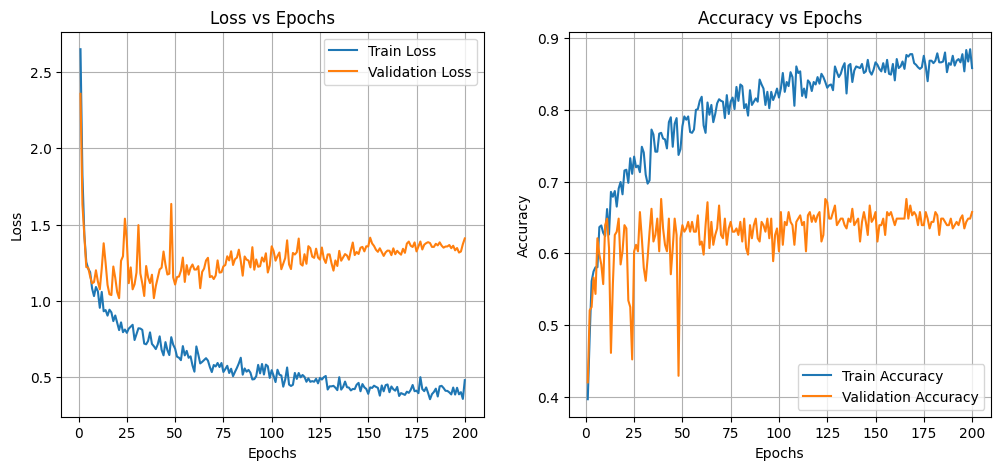

In [88]:
# Train the model with the new feature representation (Frequency + Amplitude)
model, train_losses, val_losses, train_accuracies, val_accuracies = train_mlp(X_train, y_train, X_test, y_test, num_classes, epochs=epochs, batch_size=batch_size, lr=learning_rate)

# Evaluate the model on the test set
test_accuracy = evaluate_model(model, X_test, y_test)

plot_training_results(train_losses, val_losses, train_accuracies, val_accuracies)

11. SAVING EXPERIMENT RESULTS

In [91]:
# Copy the script to save results
shutil.copyfile('./mlp fourier.ipynb', './' + results_dir + 'mlp_copy.ipynb')

'./Tests/Fourier/19/mlp_copy.ipynb'